In [9]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [22]:
class BatsmanState(TypedDict):

    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str

In [32]:
def calculate_sr(state: BatsmanState):

    sr = (state['runs']/state['balls'])*100

    return {"sr":sr}

In [24]:
def calculate_bpb(state: BatsmanState):

    bpb = state['balls']/(state['fours'] + state['sixes'])

    return {'bpb':bpb}

In [25]:
def calculate_bp(state: BatsmanState):

    bp = (((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs']) * 100
    return {'boundary_percent':bp}

In [26]:
def summary(state: BatsmanState):
    summary = f"""
Strike rate - {state['sr']} \n
Balls per boundary - {state['bpb']} \n
Boundary percent - {state['boundary_percent']}
"""
    return {'summary':summary}

In [33]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_strike_rate", calculate_sr)
graph.add_node("calculate_boundary_per_ball", calculate_bpb)
graph.add_node("calculate_boundary_percent", calculate_bp)
graph.add_node("summary", summary)

graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_boundary_per_ball")
graph.add_edge(START, "calculate_boundary_percent")

graph.add_edge("calculate_strike_rate", "summary")
graph.add_edge("calculate_boundary_per_ball", "summary")
graph.add_edge("calculate_boundary_percent", "summary")

graph.add_edge("summary", END)

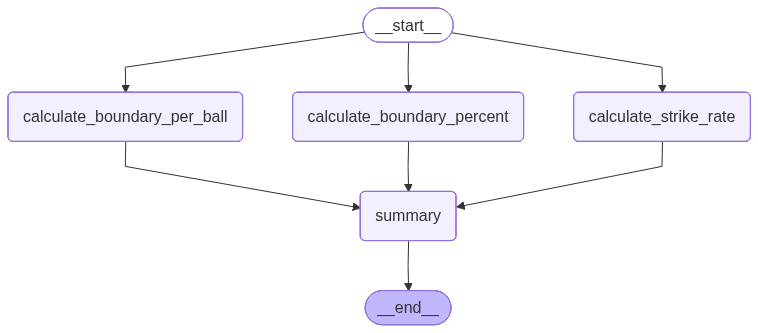

In [34]:
workflow = graph.compile()
workflow

In [29]:
initial_state = {
    "runs": 100,
    "balls": 50,
    "fours": 6,
    "sixes": 4
}

In [35]:
final_state = workflow.invoke(initial_state)

In [36]:
final_state

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': '\nStrike rate - 200.0 \n\nBalls per boundary - 5.0 \n\nBoundary percent - 48.0\n'}

In [38]:
print(final_state['summary'])


Strike rate - 200.0 

Balls per boundary - 5.0 

Boundary percent - 48.0

